In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

---
## <u>Make Dataset<u>

In [23]:
X, y = make_moons(
    n_samples = 500,
    noise = 0.1,
    random_state = 42
)

X = pd.DataFrame(X)
X.head()

,0,1
0,0.830676,-0.409936
1,0.798355,0.837612
2,1.050468,-0.485162
3,-0.258143,0.980008
4,0.330682,1.147633


---
## <u>Standardize<u>

In [24]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
X_scaled.head()

,x0,x1
0,0.367780,-1.304200
1,0.330818,1.151287
2,0.619130,-1.452264
3,-0.877373,1.431558
4,-0.204004,1.761485


---
## <u>Visualise<u>

<Axes: xlabel='x0', ylabel='x1'>

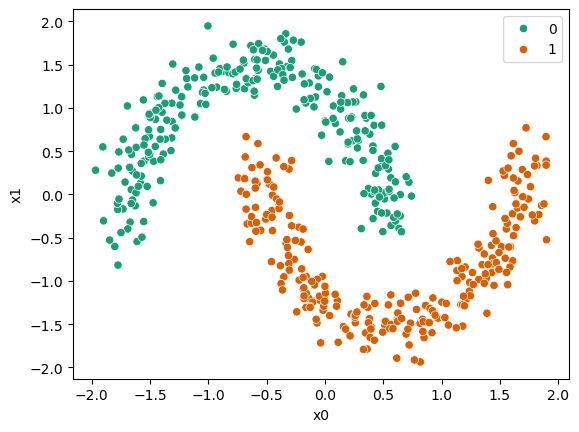

In [25]:
sns.scatterplot(
    x = X_scaled.iloc[:,0],
    y = X_scaled.iloc[:,1],
    hue = y,
    palette = "Dark2"
)

---
## <u>Make model and predict<u>

In [33]:
dbscan = DBSCAN(
    eps=0.18, # rule of thumb : eps = 0.5 to 1 if features < 10, eps = 1 to 2 if features < 20, eps > 2 if features > 20
    min_samples = 5 # rule of thumb : min. samples = 2 * no. of features
)

labels = dbscan.fit_predict(X_scaled)

---
## <u>Visualise the labels<u>

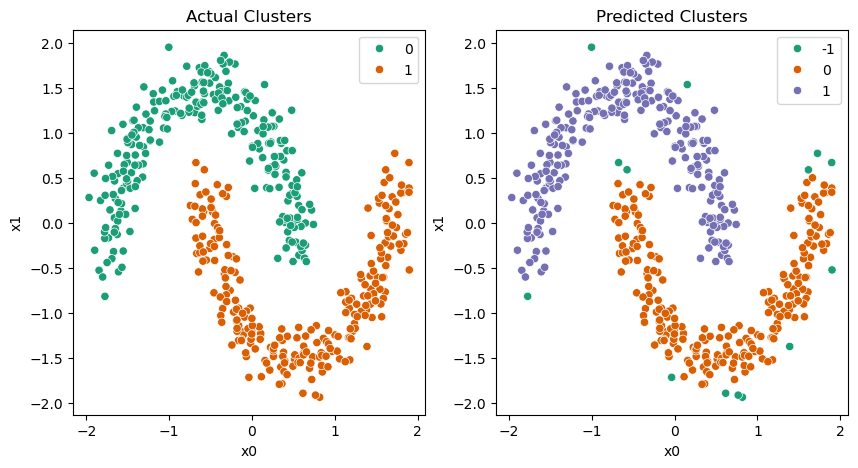

<Figure size 640x480 with 0 Axes>

In [42]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

sns.scatterplot(
    ax = ax[0],
    x = X_scaled.iloc[:,0],
    y = X_scaled.iloc[:,1],
    hue = y,
    palette = "Dark2"
)

sns.scatterplot(
    ax = ax[1],
    x = X_scaled.iloc[:,0],
    y = X_scaled.iloc[:,1],
    hue = labels,
    palette = "Dark2"
)

ax[0].set_title("Actual Clusters")
ax[1].set_title("Predicted Clusters")

plt.show()
plt.tight_layout()